In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
from utility import clean_reddit_posts, extract_case_features, extract_linguistic_features

df = pd.read_csv("cleaned_suicidality_dataset.csv", keep_default_na=False, index_col=0)

# EDA Questions

### Main Question: Does the 'Suicidal' label manifest more through emotional vocabulary or through specific grammatical structures (like self-focus and punctuation usage)?

1) Is there a statistically significant difference in the negative_emotion word usage between the two labels?
2) Is there a statistically significant difference in first-person singular pronoun usage between Suicidal and Non-Suicidal posts?
3) Is there a statistically significant difference in the death related word usage between the two labels?
4) Is there a statistically significant difference in the usage of 'absolutist' language and intense punctuation (exclamations) between Suicidal and Non-Suicidal labels?


---

## EDA Question 1: Is there a statistically significant difference in the mean negative_emotion score between the two labels?
<introduction>

To be able to analyze the emotional tone of the data, we can look at the distribution of the `negative_emotion` feature counts for "Suicidal" and "Non-Suicidal" labels.
This helps us understand how prevalent negative emotional language is in each group and whether one label consistently shows higher intensity.
We can begin by comparing group means, then visualize spread and outliers using a boxplot, and finally check statistical significance with an independent-samples test.

In [9]:
# Calculate the mean negative emotion for each label
print(df.groupby('label')['negative_emotion'].mean())

label
Non-Suicidal    0.241190
Suicidal        0.940069
Name: negative_emotion, dtype: float64


- Non-suicidal mean negative emotion = 0.241
- Suicidal mean negative emotion = 0.940

This means posts labaled suicidal have, on average about 3.9x higher than non suicidal posts. This can potentiall indicate that negative emotional language is associated with suicidal labels

To better visualize it, we create a boxplot showcasing the comparison across the 2 labels

/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_80831/1436483550.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='negative_emotion', palette='coolwarm')


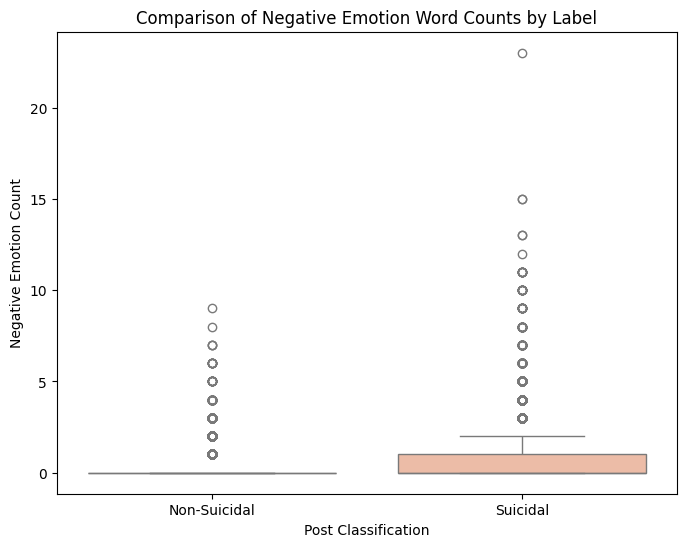

In [10]:

# Create a boxplot to compare negative_emotion across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='negative_emotion', palette='coolwarm')

plt.title('Comparison of Negative Emotion Word Counts by Label')
plt.xlabel('Post Classification')
plt.ylabel('Negative Emotion Count')
plt.show()

From the boxplot, the **Suicidal** group is shifted upward compared with the **Non-Suicidal** group, meaning its median and most values of `negative_emotion` are higher.

The box (IQR) for Suicidal posts is also at higher values, which shows that even the middle 50% of that group tends to use more negative-emotion language.

There may still be some overlap between groups, but the clear upward shift supports the earlier mean comparison and suggests a strong association between higher `negative_emotion` and the suicidal label.

### Why we use a t-test here
We use a **Welch’s independent-samples t-test** to verify whether the difference in average `negative_emotion` between **Suicidal** and **Non-Suicidal** posts is statistically meaningful, not just due to random variation.

### How it works
- It compares the two group means relative to how spread out the scores are within each group.
- **Null hypothesis ($H_0$):** both groups have the same true mean `negative_emotion`.
- **Alternative hypothesis ($H_1$):** the true means are different.
- It returns a **t-statistic** (size of difference in standardized units) and a **p-value** (how likely that difference is if $H_0$ were true).

### Decision rule
If `p < 0.05`, we reject $H_0$ and conclude there is a significant difference between groups.

In [17]:
suicidal_emo = df[df['label'] == 'Suicidal']['negative_emotion']
non_suicidal_emo = df[df['label'] == 'Non-Suicidal']['negative_emotion']

t_stat, p_value = stats.ttest_ind(suicidal_emo, non_suicidal_emo, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 35.9569
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)




In our output, the p-value is effectively 0.0000 (< 0.05), so we reject $H_0$ and conclude there is a statistically significant difference in mean `negative_emotion` between the two labels.
The Welch's t-test also showed that there is a statistically significant difference between first-person 

---

## EDA Question 2: Is there a statistically significant difference in first-person singular pronoun usage between Suicidal and Non-Suicidal posts?

<introduction>

In [12]:
# Calculate the mean first_person_singular for each label
print("Mean first_person_singular by label:")
print(df.groupby('label')['first_person_singular'].mean())

Mean first_person_singular by label:
label
Non-Suicidal    11.836727
Suicidal        20.680687
Name: first_person_singular, dtype: float64


/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_80831/4252779587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='first_person_singular', palette='coolwarm')


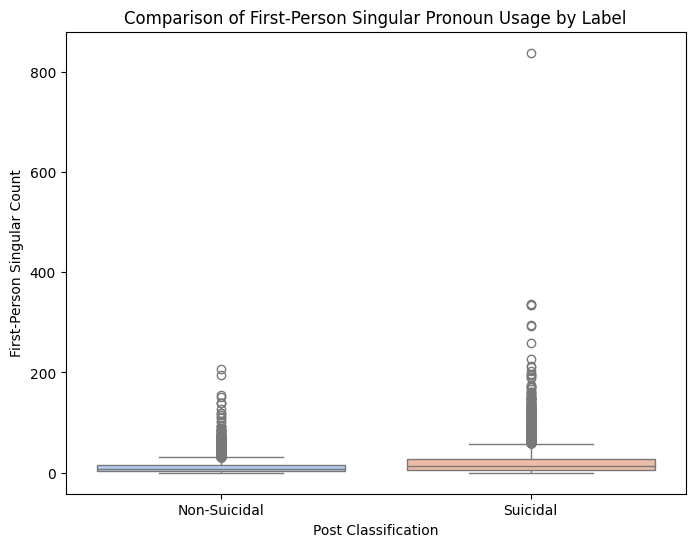

In [13]:
# Boxplot: first_person_singular across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='first_person_singular', palette='coolwarm')

plt.title('Comparison of First-Person Singular Pronoun Usage by Label')
plt.xlabel('Post Classification')
plt.ylabel('First-Person Singular Count')
plt.show()

In [14]:
suicidal_fp = df[df['label'] == 'Suicidal']['first_person_singular']
non_suicidal_fp = df[df['label'] == 'Non-Suicidal']['first_person_singular']

t_stat, p_value = stats.ttest_ind(suicidal_fp, non_suicidal_fp, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 26.4571
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The Welch's t-test showed that there is a statistically significant difference between first-person 

---

## EDA Question 3: Is there a statistically significant difference in the death related word usage between the two labels?
<introduction>

In [18]:
# Calculate the mean negative emotion for each label
print(df.groupby('label')['death_related'].mean())

label
Non-Suicidal    0.125107
Suicidal        1.811271
Name: death_related, dtype: float64


In [ ]:

# Create a boxplot to compare negative_emotion across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='death_related', palette='coolwarm')

plt.title('Comparison of Negative Emotion Word Counts by Label')
plt.xlabel('Post Classification')
plt.ylabel('Death Related Count')
plt.show()